# Introduction to Data Science – Homework 7
*COMP 5360 / MATH 4100, University of Utah, http://datasciencecourse.net/*

Due: Friday, March 20, 2026 11:59pm.

In this homework, you will use classification methods to classify handwritten digits (Part 1) and predict airline customer loyalty (Part 2). We hope these exercises will give you an idea of the broad usage of classification methods.

## Your Data
First Name: Kim
<br>
Last Name: Laanghen
<br>
E-mail: kim.lanaghen@utah.edu
<br>
UID: u1210825
<br>

In [ ]:
# imports and setup 
import pandas as pd
import numpy as np

from sklearn import tree, svm, metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import load_digits
from sklearn.preprocessing import scale

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('ggplot')

## Part 1: MNIST handwritten digits

The MNIST handwritten digit dataset is a famous test dataset containing images of handwritten digits, together with labels indicating which digit is in each image. You will see that images are just matrices with scalar values, and that we can apply the classification algorithms we studied on them.

Because both the features and the labels are present in this dataset (and labels for large datasets are generally difficult and expensive to obtain), this dataset is frequently used as a benchmark to compare various classification methods. For example, the [MNIST benchmark comparison page](https://yann.lecun.org/exdb/mnist/index.html) provides a comparison of a variety of classification methods on MNIST. (Note that the tests on that page use higher-resolution images than we will use.)

In this problem, we'll use scikit-learn to compare classification methods on the MNIST dataset. 

There are several versions of the MNIST dataset. We'll use the one that is built-into scikit-learn, described [here](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html). 

1) Classes: 10 (one for each digit)
2) Samples total: 1797
3) Samples per class: $\approx$180
4) Dimensionality: 64 (8 pixels by 8 pixels)
5) Features: integers 0-16 (grayscale value; 0 is white, 16 is black)

Here are some examples of the images. Note that the digits have been size-normalized and centered in a fixed-size ($8\times8$ pixels) image.

<img src="http://scikit-learn.org/stable/_images/sphx_glr_plot_digits_classification_001.png" width="500">

Note that we will scale the data before running them through our algorithms. You can read details about scaling and why it's important [here](http://scikit-learn.org/stable/modules/preprocessing.html#standardization-or-mean-removal-and-variance-scaling).

In [12]:
digits = load_digits()
X = digits.data
X = scale(digits.data)
y = digits.target
print(type(X))

n_samples, n_features = X.shape
n_digits = len(np.unique(digits.target))
print("n_digits: %d, n_samples %d, n_features %d" % (n_digits, n_samples, n_features))

<class 'numpy.ndarray'>
n_digits: 10, n_samples 1797, n_features 64


In [13]:
# this is what one digit (a zero) looks like
print("===\nThe digit")
print(digits.target[0])

print("===\nThe raw data")
print(digits.images[0])

print("===\nThe scaled data")
print(X[0])

===
The digit
0
===
The raw data
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
===
The scaled data
[ 0.         -0.33501649 -0.04308102  0.27407152 -0.66447751 -0.84412939
 -0.40972392 -0.12502292 -0.05907756 -0.62400926  0.4829745   0.75962245
 -0.05842586  1.12772113  0.87958306 -0.13043338 -0.04462507  0.11144272
  0.89588044 -0.86066632 -1.14964846  0.51547187  1.90596347 -0.11422184
 -0.03337973  0.48648928  0.46988512 -1.49990136 -1.61406277  0.07639777
  1.54181413 -0.04723238  0.          0.76465553  0.05263019 -1.44763006
 -1.73666443  0.04361588  1.43955804  0.         -0.06134367  0.8105536
  0.63011714 -1.12245711 -1.06623158  0.66096475  0.81845076 -0.08874162
 -0.03543326  0.74211893  1.15065212 -0.86867056  0.11012973  0.53761116
 -0.757435

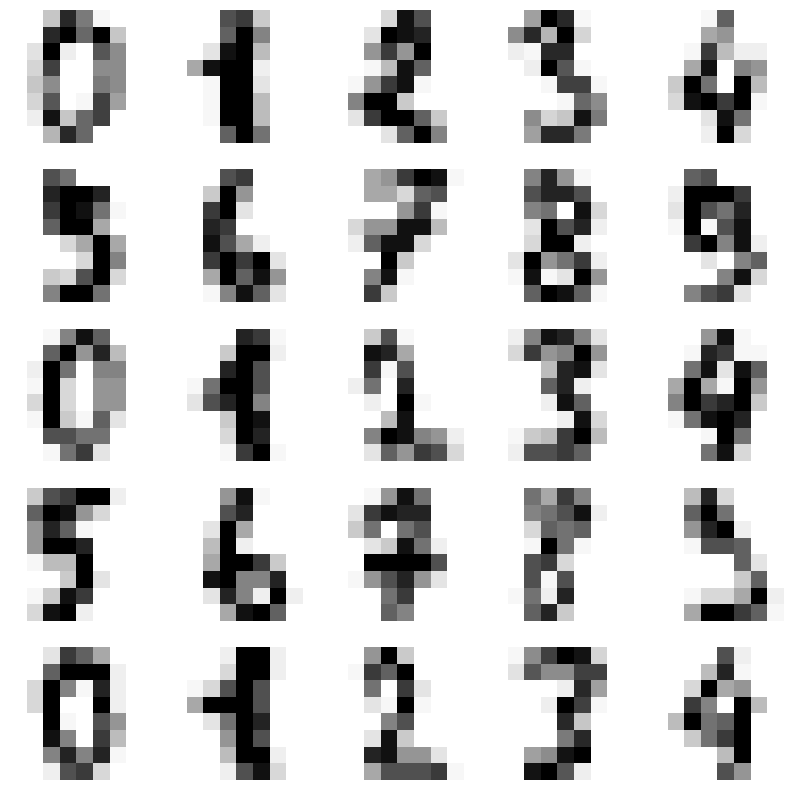

In [14]:
# plot a few of the images
plt.figure(figsize= (10, 10))    
for ii in np.arange(25):
    plt.subplot(5, 5, ii+1)
    plt.imshow(np.reshape(digits.images[ii,:],(8,8)), cmap='Greys',interpolation='nearest')
    plt.axis('off')
plt.show()

You might find [this scikit-learn webpage](https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html#sphx-glr-auto-examples-classification-plot-digits-classification-py) to be generally helpful for this exercise. 

### Task 1.1: Classification with Support Vector Machines (SVM)

1. Split the data into a training and test set using `train_test_split(X, y, random_state=1, test_size=0.8)`.
2. Use SVM with an `rbf` kernel and `C=100` to build a classifier from the training set.
3. Evaluate the accuracy and compute the confusion matrix on the test set. Identify the most common mistake. 
*Note: this corresponds to the largest off-diagonal entry of the confusion matrix.*
4. For the most common mistake, print all of the misclassified digits.
5. Use `cross_val_score` to evaluate accuracy for 100 values of C between 1 and 100. What is the best value?
6. Test on raw (non-scaled) data and report the accuracy score for different settings of `gamma`. Use the C value determined previously.

In [15]:
# Part 1: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.8)

In [16]:
# Part 2: SVM with an rbf kernel
model_svm = svm.SVC(kernel='rbf', gamma=0.001, C=100.)
model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)
print("SVM Accuracy: %.2f" % metrics.accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.96


Confusion matrix:
[[130   0   0   0   0   0   0   0   0   0]
 [  0 139   2   0   1   0   0   0   7   0]
 [  0   3 138   0   0   0   0   0   1   0]
 [  0   0   1 141   0   0   0   1   3   1]
 [  0   0   0   0 152   0   0   0   0   0]
 [  0   0   0   2   0 143   0   0   1   1]
 [  0   2   0   0   0   0 143   0   1   0]
 [  0   0   0   0   1   0   0 138   0   1]
 [  0  10   1   1   1   0   0   0 118   2]
 [  0   1   0   3   0   3   0   0   3 142]]


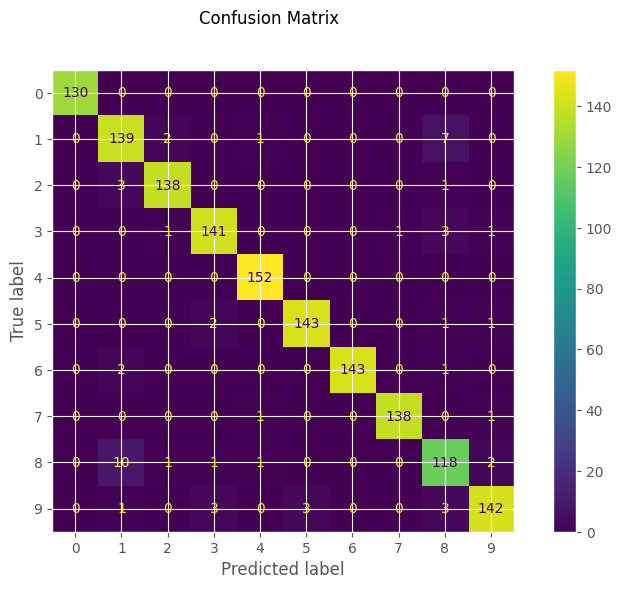

In [ ]:
# Part 3: confusion matrix
disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
disp.figure_.suptitle("Confusion Matrix")
print(f"Confusion matrix:\n{disp.confusion_matrix}")

plt.show()

In [20]:
# zero out the diagonal (correct predictions)
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# find the largest off-diagonal value
true_label, predicted_label = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)

print(f"Most common mistake: true digit {true_label} predicted as {predicted_label}")
print(f"Happened {cm_no_diag[true_label, predicted_label]} times")

Most common mistake: true digit 8 predicted as 1
Happened 10 times


In [ ]:
# Part 4: print all the missclassified digits


Number of missclassified digits: 54


In [9]:
# Part 5

In [ ]:
# Part 6

### Task 1.2: Prediction with k-nearest neighbors
Repeat Task 1.1 using k-nearest neighbors (k-NN). 
For part 2, use k=10. 
For part 5, find the best value of k between 1 and 10. 
You do not need to handle non-scaled data for k-NN.

In [ ]:
# Part 1

In [ ]:
# Part 2

In [12]:
# Part 3

In [13]:
# Part 4

In [14]:
# Part 5

# Part 2: Predicting Airline Customer Loyalty

In this problem, you will use classification tools to predict whether a customer is a "Loyal Customer" or a "disloyal Customer". This information is critical for the airline's retention strategy.

### Task 2.1 Import and Preprocessing
* Use `pandas.read_csv()` to import the dataset `airline_survey.csv`. 
* Convert ordinal and categorical columns ('Gender', 'Type of Travel', 'Class', 'Customer Type') to numerical data.
* Drop all rows with NaN values.

In [15]:
# your solution goes here

### Task 2.2 Predictor and Predicted Variable
* Export the predictor variables as a numpy array called *X*. Drop the 'id' and 'Customer Type' columns for this array.
* Export the 'Customer Type' column as a binary numpy array called *y* (e.g., Loyal=1, Disloyal=0).
* Print the *y* array.

In [16]:
# your solution goes here

### Task 2.3 Classification using k-NN
Develop a k-NN classification model to predict loyalty. Use cross-validation to choose the best value of k. Plot the accuracy for various values of k (e.g., 1 to 30).

In [17]:
# your solution goes here

### Task 2.4 Classification using SVM
Develop an SVM classification model for loyalty prediction. Show the results of cross-validation.

*Hint: Use a subset of the data (e.g., 4,000 samples) if processing time is too long*.

In [18]:
# your solution goes here

### Task 2.5 Classification using Decision Trees
Develop a decision tree model. Use cross-validation to tune `max_depth` and `min_samples_split`. Show the cross-validation output and optimal parameters.

In [ ]:
max_depths = [5, 10, 15, 20]
min_splits = [10, 100, 200, 400, 800]

# your solution goes here


### Task 2.6 Describe Your Findings
1. Which method (k-NN, SVM, Decision Tree) was most effective at predicting loyalty?
2. How did parameter changes (like $k$ or tree depth) affect accuracy?
3. Which model provided the most useful insights into why a customer is loyal?

**Your Solution:** TODO